# Exploration — SoilGrids (Variables pédologiques)

Fichiers concernés :
- `data/EnvironmentalValues/SoilGrids/GLC25-PA-train-soilgrids.csv`
- `data/EnvironmentalValues/SoilGrids/GLC25-PA-test-soilgrids.csv`

9 variables pédologiques extraites à 5-15cm de profondeur (source : SoilGrids, résolution ~1km) :
- `bdod` : densité apparente (bulk density)
- `cec` : capacité d'échange cationique
- `cfvo` : fraction volumique de fragments grossiers
- `clay` : teneur en argile
- `nitrogen` : azote total
- `phh2o` : pH à l'eau
- `sand` : teneur en sable
- `silt` : teneur en limon
- `soc` : carbone organique

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SOIL_DIR = '../data/EnvironmentalValues/SoilGrids/'

train = pd.read_csv(SOIL_DIR + 'GLC25-PA-train-soilgrids.csv')
test  = pd.read_csv(SOIL_DIR + 'GLC25-PA-test-soilgrids.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
train.head()

Train shape: (88987, 10)
Test  shape: (14829, 10)


,surveyId,Soilgrid-bdod,Soilgrid-cec,Soilgrid-cfvo,Soilgrid-clay,Soilgrid-nitrogen,Soilgrid-phh2o,Soilgrid-sand,Soilgrid-silt,Soilgrid-soc
0,212,140.0,214.0,151.0,292.0,159.0,73.0,284.0,422.0,176.0
1,222,120.0,225.0,101.0,94.0,379.0,58.0,650.0,255.0,609.0
2,243,115.0,261.0,86.0,131.0,373.0,54.0,750.0,117.0,672.0
3,324,118.0,179.0,117.0,225.0,230.0,57.0,238.0,535.0,302.0
4,333,138.0,233.0,176.0,328.0,250.0,71.0,231.0,439.0,257.0


## 1. Valeurs manquantes

In [2]:
print('=== Valeurs manquantes TRAIN ===')
missing_train = train.isnull().sum()
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else 'Aucune')

print('\n=== Valeurs manquantes TEST ===')
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else 'Aucune')

=== Valeurs manquantes TRAIN ===
Soilgrid-bdod        8573
Soilgrid-cec         7512
Soilgrid-cfvo        7512
Soilgrid-clay        7512
Soilgrid-nitrogen    7512
Soilgrid-phh2o       7512
Soilgrid-sand        7512
Soilgrid-silt        7512
Soilgrid-soc         8573
dtype: int64

=== Valeurs manquantes TEST ===
Soilgrid-bdod        1810
Soilgrid-cec         1794
Soilgrid-cfvo        1794
Soilgrid-clay        1794
Soilgrid-nitrogen    1794
Soilgrid-phh2o       1794
Soilgrid-sand        1794
Soilgrid-silt        1794
Soilgrid-soc         1810
dtype: int64


## 2. Statistiques descriptives

In [3]:
soil_cols = [c for c in train.columns if c != 'surveyId']
train[soil_cols].describe().round(2)

,Soilgrid-bdod,Soilgrid-cec,Soilgrid-cfvo,Soilgrid-clay,Soilgrid-nitrogen,Soilgrid-phh2o,Soilgrid-sand,Soilgrid-silt,Soilgrid-soc
count,80414.00,81475.00,81475.00,81475.00,81475.00,81475.00,81475.00,81475.00,80414.00
mean,120.26,216.91,98.91,163.71,296.44,59.58,547.53,287.29,473.46
std,9.58,43.80,40.40,83.62,103.52,5.82,187.72,114.10,189.35
min,81.00,90.00,30.00,30.00,108.00,42.00,49.00,30.00,106.00
25%,114.00,185.00,73.00,102.00,231.00,56.00,392.00,215.00,339.00
50%,119.00,215.00,86.00,140.00,274.00,59.00,592.00,268.00,444.00
75%,127.00,249.00,111.00,219.00,337.00,63.00,675.00,368.00,575.00
max,155.00,411.00,369.00,518.00,1247.00,80.00,931.00,732.00,2019.00


## 3. Distribution des variables

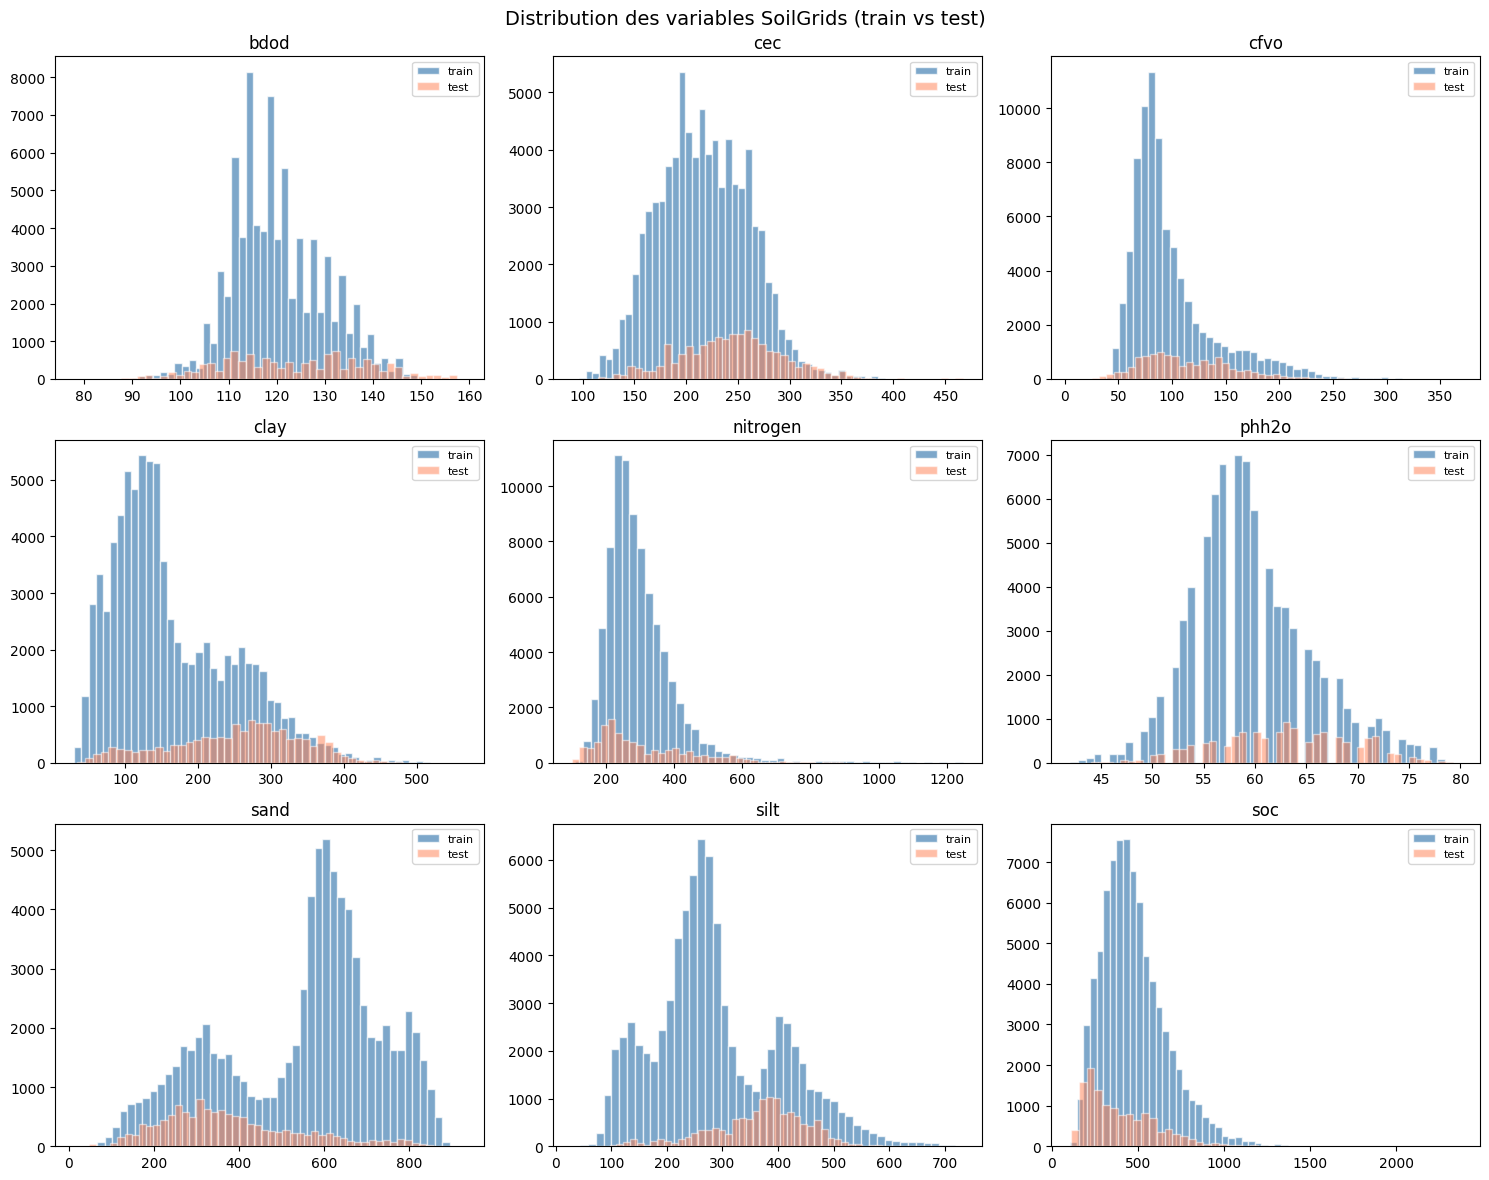

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(soil_cols):
    axes[i].hist(train[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.7, label='train')
    axes[i].hist(test[col].dropna(), bins=50, color='coral', edgecolor='white', alpha=0.5, label='test')
    axes[i].set_title(col.replace('Soilgrid-', ''))
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution des variables SoilGrids (train vs test)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Matrice de corrélation

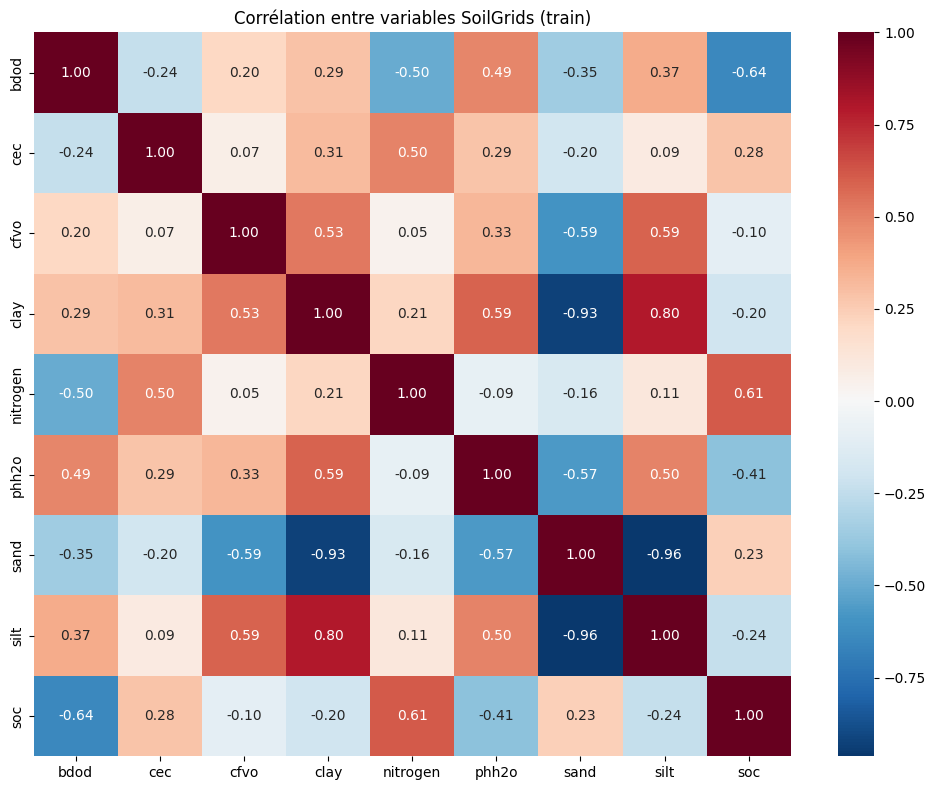

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = train[soil_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=[c.replace('Soilgrid-', '') for c in soil_cols],
            yticklabels=[c.replace('Soilgrid-', '') for c in soil_cols],
            ax=ax)
ax.set_title('Corrélation entre variables SoilGrids (train)')
plt.tight_layout()
plt.show()

## 5. Comparaison train / test (boxplot)

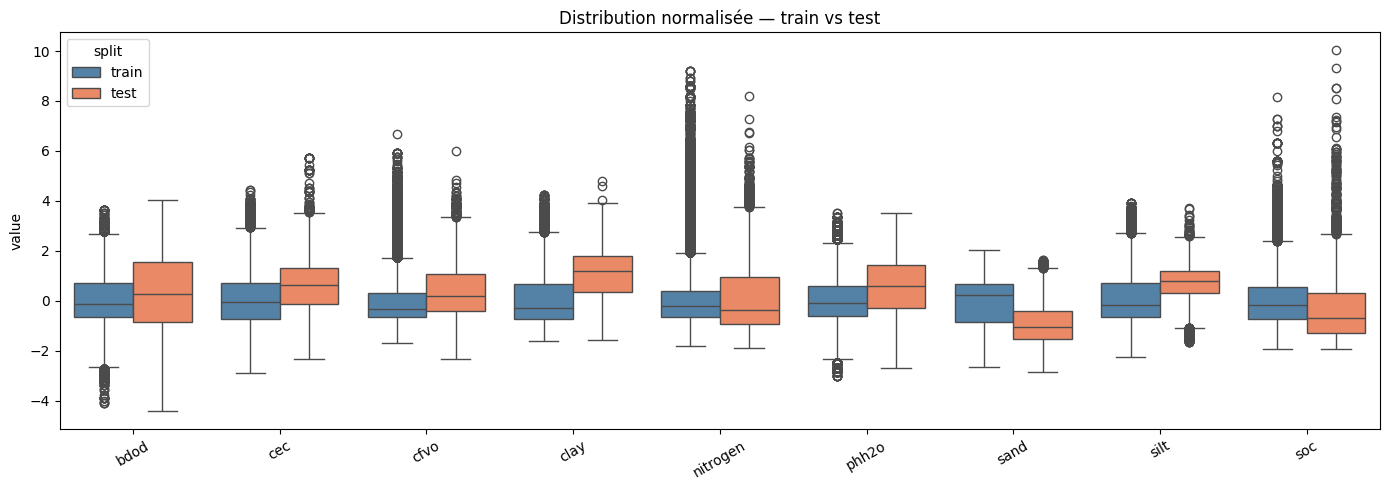

In [6]:
# Normaliser pour comparaison
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train[soil_cols]), columns=soil_cols)
test_scaled  = pd.DataFrame(scaler.transform(test[soil_cols]), columns=soil_cols)

train_scaled['split'] = 'train'
test_scaled['split']  = 'test'
combined = pd.concat([train_scaled, test_scaled])

fig, ax = plt.subplots(figsize=(14, 5))
combined_melt = combined.melt(id_vars='split', value_vars=soil_cols)
combined_melt['variable'] = combined_melt['variable'].str.replace('Soilgrid-', '')
sns.boxplot(data=combined_melt, x='variable', y='value', hue='split', ax=ax,
            palette={'train': 'steelblue', 'test': 'coral'})
ax.set_title('Distribution normalisée — train vs test')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()